In [1]:
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import sklearn.metrics as met

In [2]:
from datetime import datetime
import numpy as np
import matplotlib.colors as mcolors

In [3]:
raw_data = pd.read_csv("Plant Report All.csv", sep=";")
raw_data

,Date,Daily PV Yield(kWh),Daily inverter output (kWh),Daily exported energy(kWh),Daily imported energy(kWh),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),Day of the week,daylight_duration (s),sunshine_duration (s),precipitation_sum (mm)
0,2024-05-23,4.9,5.9,0.94,7.08,16.6,8.5,12.8,Thursday,57225.66,50967.36,1.0
1,2024-05-24,17.5,16.8,0.07,25.30,16.7,9.5,13.2,Friday,57370.25,39951.46,9.8
2,2024-05-25,26.1,23.8,0.35,11.92,18.5,10.0,13.8,Saturday,57510.79,50621.47,2.7
3,2024-05-26,30.1,28.4,0.38,12.23,19.1,10.2,14.9,Sunday,57647.06,50556.42,5.6
4,2024-05-27,23.8,21.9,0.30,8.16,19.4,11.5,15.2,Monday,57778.87,38785.89,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...
261,2025-02-08,28.0,36.0,3.49,49.97,0.3,-3.6,-2.1,Saturday,34801.76,29422.73,0.0
262,2025-02-09,34.9,43.0,11.61,39.10,2.9,-6.0,-2.6,Sunday,35013.74,30648.23,0.0
263,2025-02-10,14.2,23.1,0.85,60.40,5.3,-6.6,-2.1,Monday,35226.74,30736.73,0.0
264,2025-02-11,31.3,39.6,11.62,44.45,2.6,-7.5,-2.4,Tuesday,35440.55,30518.99,0.0


In [4]:
raw_data["Date"] = [datetime.strptime(x, '%Y-%m-%d') for x in raw_data["Date"]]

float_var = ["Daily imported energy(kWh)", "Daily PV Yield(kWh)", "Daily inverter output (kWh)", "Daily exported energy(kWh)", "temperature_2m_max (°C)", "temperature_2m_min (°C)", "temperature_2m_mean (°C)", "daylight_duration (s)", "sunshine_duration (s)", "precipitation_sum (mm)"]
for i in float_var:
    raw_data[i] = [float(x) for x in raw_data[i]]

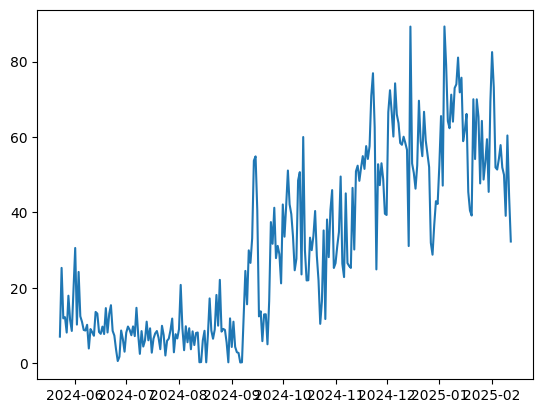

In [5]:
plt.plot(raw_data["Date"], raw_data["Daily imported energy(kWh)"])

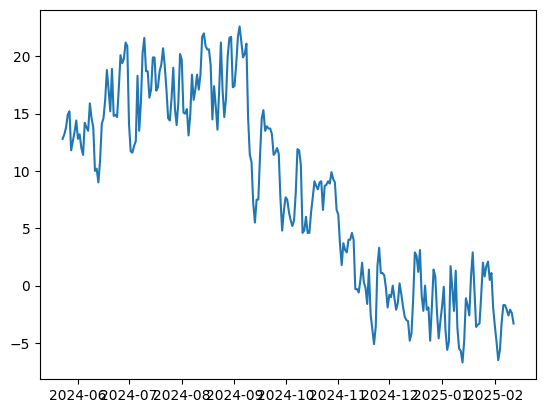

In [6]:
plt.plot(raw_data["Date"], raw_data["temperature_2m_mean (°C)"])

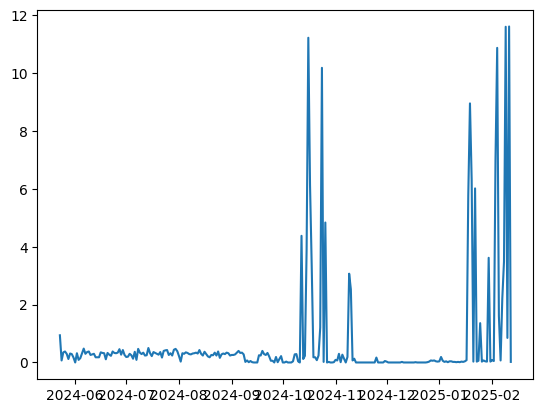

In [7]:
plt.plot(raw_data["Date"], raw_data["Daily exported energy(kWh)"])

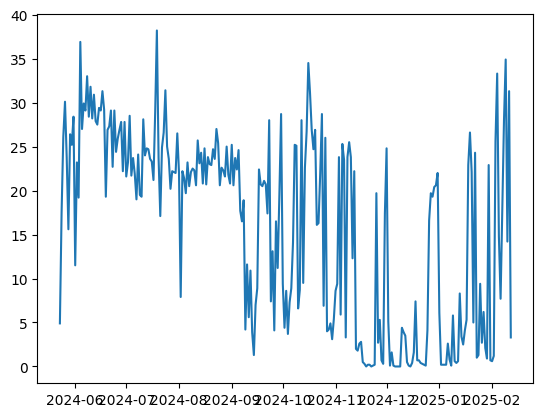

In [8]:
plt.plot(raw_data["Date"], raw_data["Daily PV Yield(kWh)"])

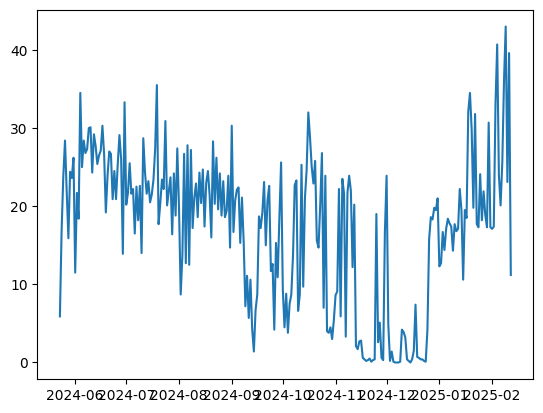

In [9]:
plt.plot(raw_data["Date"], raw_data["Daily inverter output (kWh)"])

In [10]:
raw_data["All power"] = raw_data["Daily imported energy(kWh)"] + raw_data["Daily inverter output (kWh)"] - raw_data["Daily exported energy(kWh)"]

In [11]:
def plot_graph(data, x_axis, y_axis, title):
    
    fig, ax = plt.subplots()
    grouped = data.groupby('Day of the week')
    keys = grouped.groups.keys()
    col = mcolors.TABLEAU_COLORS
    colors = dict(zip(keys, list(col.values())[0:len(keys)]))
    # colors = {"Monday": "red", "Tuesday": "red", "Wednesday":"red", "Thursday": "red", "Friday": "red", "Saturday": "blue", "Sunday":"blue"}
    
    for key, group in grouped:
        group.plot(ax=ax, kind="scatter", x=x_axis, y=y_axis, label=key, color=colors[key])
    plt.title(title)
    plt.show()

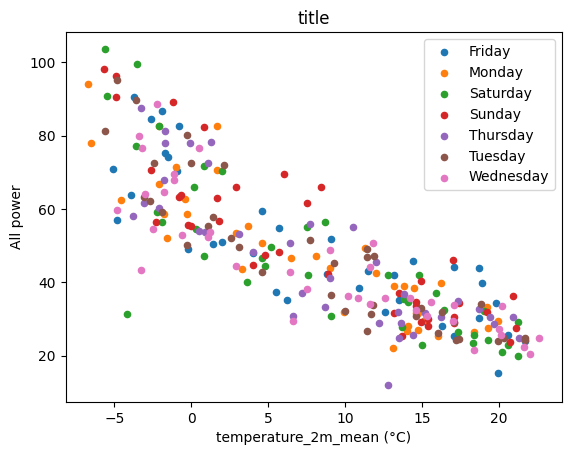

In [12]:
plot_graph(raw_data, "temperature_2m_mean (°C)", "All power", "title")

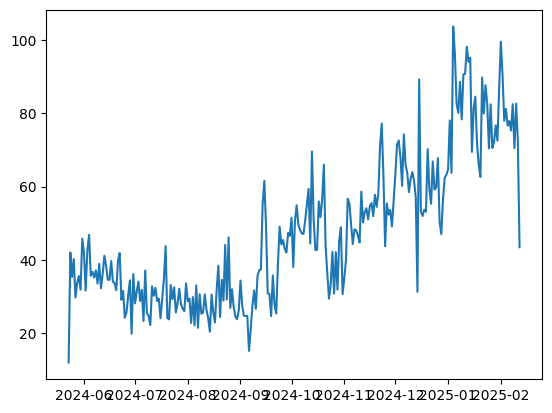

In [13]:
plt.plot(raw_data["Date"], raw_data["All power"])

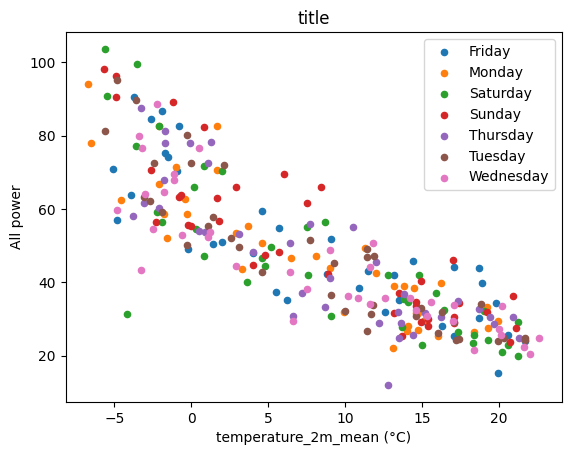

In [14]:
plot_graph(raw_data, "temperature_2m_mean (°C)", "All power", "title")

In [15]:
data_with_flags = raw_data.copy()
grouped = raw_data.groupby('Day of the week')
days = grouped.groups.keys()

for name in days:
    data_with_flags[name] = [ 1 if n == name else 0 for n in data_with_flags["Day of the week"]]


In [20]:
# input_var = data_with_flags[[*days, "temperature_2m_mean (°C)", "daylight_duration (s)"]]
input_var = data_with_flags[["temperature_2m_mean (°C)"]]

output_var = data_with_flags[["All power"]]
x_train, x_test, y_train, y_test = train_test_split(input_var, output_var, test_size=0.3, train_size=0.7)
linear_model = LinearRegression().fit(x_train, y_train)
linear_model.score(x_test, y_test)

0.7644448829311671

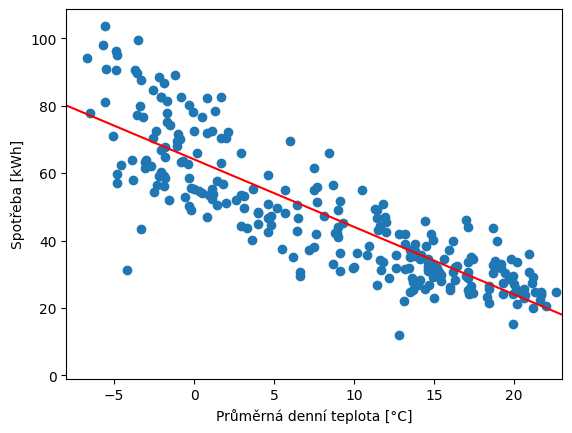

In [35]:
plt.scatter(raw_data["temperature_2m_mean (°C)"], raw_data["All power"])
plt.xlim(-8, 23)
x1, y1 = [-10, 30],[84.11, 3.96]
plt.plot(x1, y1, color = 'r')
plt.xlabel("Průměrná denní teplota [°C]")
plt.ylabel("Spotřeba [kWh]")
plt.show()

In [22]:
pred = pd.DataFrame({"temperature_2m_mean (°C)": [2.2]})
linear_model.predict(pred)

array([[59.67685884]])

print(linear_model.coef_)
print(linear_model.intercept_)

In [23]:
print(linear_model.coef_)
print(linear_model.intercept_)

[[-2.00397991]]
[64.08561464]


In [ ]:
data_with_interaction = data_with_flags.copy()
for name in days:
    data_with_interaction[name] = data_with_interaction[name]*data_with_interaction["All power"]

In [ ]:
days_power = [sum(data_with_interaction[x]) / sum(data_with_flags[x]) for x in days]

In [ ]:
plt.bar(days, days_power)

NameError: name 'newline' is not defined